# Code for finite sets of performances
© Piérard Sébastien, 2026

## Choose the performances that we want to rank

In [1]:
# Let us choose the example of CADA-RRE: Cerebral Aneurysm Rupture Risk Estimation
# Data obtained from https://cada-rre.grand-challenge.org/evaluation/challenge/leaderboard/
json_file_path = 'data/CADA-RRE.json'

## Various imports

In [2]:
import json
import numpy as np
import pandas as pd
from IPython.display import display, HTML
import scipy
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from tqdm import tqdm

## Load data

In [3]:
def load_json ( file_path ) :

    with open(file_path) as data_file:
        data = json.load(data_file)
    
    ids = list ( data.keys () )
    num_tn = np.asarray([ data[id]['num_tn'] for id in ids ])
    num_fp = np.asarray([ data[id]['num_fp'] for id in ids ])
    num_fn = np.asarray([ data[id]['num_fn'] for id in ids ])
    num_tp = np.asarray([ data[id]['num_tp'] for id in ids ])
    
    def get_link ( id ) :
        return '<a href="' + data[id]['url'] + '">' + id + '</a>'
    
    link = [ get_link(id) for id in ids ]
    pr = num_tp/(num_fp+num_tp)
    pr = np.fmax(0.0,pr) # The limit of F-beta when beta -> 0 is 0 is the prior of the positive class is not zero.
    f1 = 2.0*num_tp/(num_fp+num_fn+2.0*num_tp)
    re = num_tp/(num_fn+num_tp)
    
    data = {
        "link": link,
        "tn": num_tn,
        "fp": num_fp,
        "fn": num_fn,
        "tp": num_tp,
        "Pr(P)": pr,
        "F1(P)": f1,
        "Re(P)": re
    }
    df = pd.DataFrame(data)
    
    html_table = HTML(df.to_html(escape=False))
    display ( html_table )

    tot = num_tn + num_fp + num_fn + num_tp
    ptn = num_tn / tot
    pfp = num_fp / tot
    pfn = num_fn / tot
    ptp = num_tp / tot

    return ptn, pfp, pfn, ptp

ptn, pfp, pfn, ptp = load_json ( json_file_path )

/var/folders/q3/f1blbv4176jcwk6n52fxgw180000gn/T/ipykernel_97598/2777120132.py:16: RuntimeWarning: invalid value encountered in divide
  pr = num_tp/(num_fp+num_tp)


,link,tn,fp,fn,tp,Pr(P),F1(P),Re(P)
0,014074c9-4e96-4b95-9604-4d64d3dd9c24,15,4,1,10,0.714286,0.800000,0.909091
1,18a26906-745b-43b1-93c6-019278cfa216,14,5,7,4,0.444444,0.400000,0.363636
2,196a03fc-27f4-4781-908c-dab649c08678,18,1,9,2,0.666667,0.285714,0.181818
3,1e24a4e5-179a-4082-88e6-459c55c1b43a,12,7,3,8,0.533333,0.615385,0.727273
4,297b7b2e-c188-47fd-bbc9-738e8a1dfa70,19,0,9,2,1.000000,0.307692,0.181818
5,2d67e02e-cbb9-48cb-b3af-ef5abd6b361d,16,3,7,4,0.571429,0.444444,0.363636
6,37e0f334-872a-4ca2-98e8-efd1b532114a,18,1,9,2,0.666667,0.285714,0.181818
7,4653e5c2-cbb2-40ae-9e7b-4db9f49cbacb,12,7,1,10,0.588235,0.714286,0.909091
8,47ea8087-80b7-45fe-96e6-a63b7a6879ff,12,7,3,8,0.533333,0.615385,0.727273
9,4e7532ad-d555-4d9e-b295-89df62a29173,18,1,8,3,0.750000,0.400000,0.272727


In [4]:
def get_priors ( ptn, pfp, pfn, ptp ) :
    
    prior_pos = pfn + ptp
    prior_pos_min = np.min ( prior_pos )
    prior_pos_max = np.max ( prior_pos )
    
    if not np.isclose ( prior_pos_min, prior_pos_max ) :
        print ( 'The priors are not fixed. Impossible to display a ROC space.' )
        print ( '    Min prior pos =', prior_pos_min )
        print ( '    Max prior pos =', prior_pos_max )
        return np.nan, np.nan
    
    prior_pos = np.mean ( prior_pos )
    prior_neg = 1.0 - prior_pos
    return prior_neg, prior_pos

## Display the performances in the ROC space, with maps of $Pr$, $F_1$, and $Re$

In [5]:
def values_to_ranks ( vals ) :
    
    vals = np.asarray(vals[:])
    idxs = np.argsort(vals)
    
    # num_lt = [ sum([v < val for v in vals]) for val in vals ]
    num_lt = np.searchsorted(vals, vals, side='left', sorter=idxs)
    
    # num_le = [ sum([v <= val for v in vals]) for val in vals ]
    num_le = np.searchsorted(vals, vals, side='right', sorter=idxs)

    N = vals.size
    num_gt = N - num_le
    num_ge = N - num_lt
    
    min_ranks = 1 + num_gt
    max_ranks = num_ge
    
    ranks = ( min_ranks + max_ranks ) * 0.5
    return ranks

/var/folders/q3/f1blbv4176jcwk6n52fxgw180000gn/T/ipykernel_97598/1807276893.py:37: RuntimeWarning: invalid value encountered in divide
  mat_fbeta = mat_fbeta_ok / ( mat_fbeta_ok + mat_fbeta_ko )
/var/folders/q3/f1blbv4176jcwk6n52fxgw180000gn/T/ipykernel_97598/1807276893.py:41: RuntimeWarning: invalid value encountered in divide
  fbeta = fbeta_ok / ( fbeta_ok + fbeta_ko )


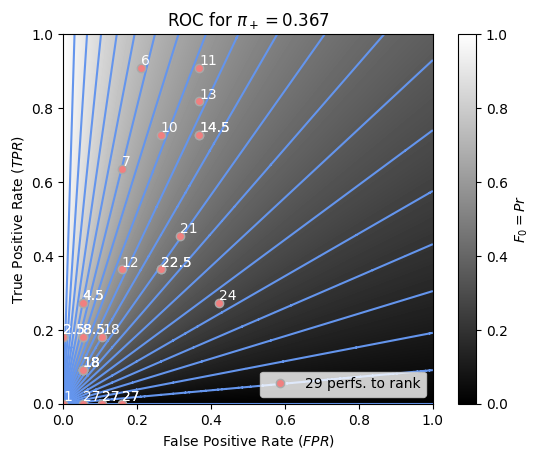

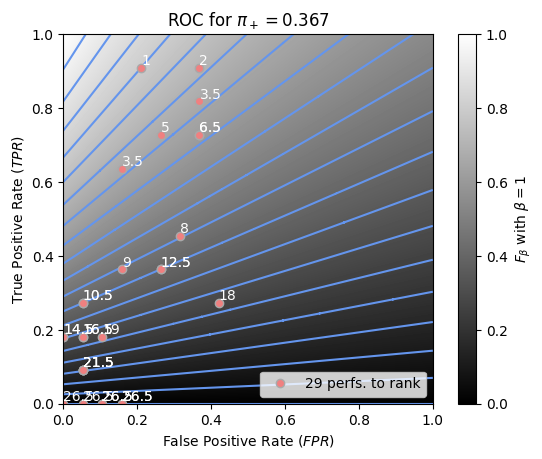

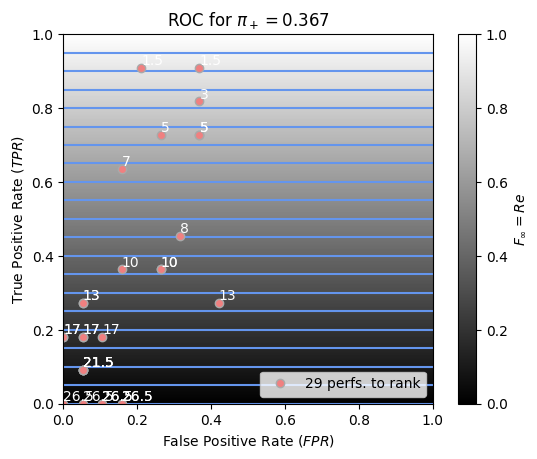

In [6]:
def display_roc ( ptn, pfp, pfn, ptp, beta ) :

    assert ( np.all ( ptn >= 0.0 ) )
    assert ( np.all ( pfp >= 0.0 ) )
    assert ( np.all ( pfn >= 0.0 ) )
    assert ( np.all ( ptp >= 0.0 ) )
    tot = ptn+pfp+pfn+ptp
    assert ( np.all ( np.isclose ( tot, 1.0 ) ) )
    N = len(tot)
    
    assert ( beta >= 0.0 )
    beta_sq = beta * beta
    
    fpr = pfp / ( ptn + pfp )
    tpr = ptp / ( pfn + ptp )

    prior_neg, prior_pos = get_priors ( ptn, pfp, pfn, ptp )

    roc_grid_size = 1000
    min_fpr, max_fpr = 0, 1 # 0, np.max(fpr)
    min_tpr, max_tpr = 0, 1 # np.min(tpr), 1
    vec_fpr = np.linspace ( min_fpr, max_fpr, roc_grid_size )
    vec_tpr = np.linspace ( min_tpr, max_tpr, roc_grid_size )
    mat_fpr, mat_tpr = np.meshgrid ( vec_fpr , vec_tpr , indexing='xy' )
    mat_ptn = ( 1 - mat_fpr ) * prior_neg
    mat_pfp = mat_fpr * prior_neg
    mat_pfn = ( 1 - mat_tpr ) * prior_pos
    mat_ptp = mat_tpr * prior_pos

    a = 1
    if np.isinf ( beta ) :
        b = 1
    else :
        b = beta_sq / ( 1.0 + beta_sq )
    mat_fbeta_ok = (1-a) * mat_ptn + a * mat_ptp
    mat_fbeta_ko = (1-b) * mat_pfp + b * mat_pfn
    mat_fbeta = mat_fbeta_ok / ( mat_fbeta_ok + mat_fbeta_ko )
    
    fbeta_ok = (1-a) * ptn + a * ptp
    fbeta_ko = (1-b) * pfp + b * pfn
    fbeta = fbeta_ok / ( fbeta_ok + fbeta_ko )
    ranks = values_to_ranks ( fbeta )
    
    fig, ax = plt.subplots ()
    # extent is (left, right, bottom, top)
    im = ax.imshow ( mat_fbeta, extent=(min_fpr, max_fpr,min_tpr, max_tpr), origin='lower', interpolation='bilinear', cmap='gray', vmin=0.0, vmax=1.0 )
    cs = ax.contour ( vec_fpr, vec_tpr, mat_fbeta, levels=np.linspace(0,1,21), colors='cornflowerblue' )
    #ax.clabel ( cs, inline=True )#, fontsize=tiny )
    pointcloud_perfs, = ax.plot ( fpr, tpr, 'o', color='darkgrey', markerfacecolor='lightcoral', markersize=6, label='{} perfs. to rank'.format(N) )
    for i in range ( N ) :
        ax.text ( fpr[i], tpr[i], '{:g}'.format(ranks[i]), color='w', fontsize=10, va='bottom' )
    ax.set_xlim ( [min_fpr, max_fpr] )
    ax.set_ylim ( [min_tpr, max_tpr] )
    ax.set_xlabel ( 'False Positive Rate ($FPR$)' )
    ax.set_ylabel ( 'True Positive Rate ($TPR$)' )
    ax.set_aspect ( 'auto' )
    ax.set_title ( 'ROC for $\\pi_+={:.3f}$'.format ( prior_pos ) )
    if beta == 0.0 :
        label = r'$F_0 = Pr$'
    elif np.isinf ( beta ) :
        label = r'$F_\infty = Re$'
    else :
        label = r'$F_{{\beta}}$ with $\beta={:g}$'.format(beta)
    cbar = fig.colorbar(im, ax=ax, label=label )
    
    handles = [
        pointcloud_perfs,
    ]
    ax.legend(handles=handles, loc='lower right')
    ax.set_aspect("equal")
    plt.show ()

display_roc ( ptn, pfp, pfn, ptp, 0.0 )
display_roc ( ptn, pfp, pfn, ptp, 1.0 )
display_roc ( ptn, pfp, pfn, ptp, np.inf )

In [7]:
def ptn_pfp_pfn_ptp_to_pr_re ( ptn, pfp, pfn, ptp ) :
    pr = ptp / ( pfp + ptp )
    pr = np.fmax(0.0,pr) # The limit of F-beta when beta -> 0 is 0 is the prior of the positive class is not zero.
    re = ptp / ( pfn + ptp )
    return pr, re

pr, re = ptn_pfp_pfn_ptp_to_pr_re ( ptn, pfp, pfn, ptp )

/var/folders/q3/f1blbv4176jcwk6n52fxgw180000gn/T/ipykernel_97598/3451071632.py:2: RuntimeWarning: invalid value encountered in divide
  pr = ptp / ( pfp + ptp )


In [8]:
def remove_duplicates ( pr, re ) :
    
    N = max ( len(pr), len(re) )
    assert len(pr) == N
    assert len(re) == N

    keep = np.zeros ( N, dtype=bool )
    for i in range ( N ) :
        keep[i] = True
        for j in range ( N ) :
            if j <= i :
                continue
            same = True
            for score in [pr, re] :
                if score[i] != score[j] :
                    same = False
            if same :
                keep[i] = False
                print ( 'removing entity', i, 'because it has the same (pr,re) as the entity', j )
        
    pr = pr [ keep ]
    re = re [ keep ]
    
    N = np.sum ( keep )
    print ( 'There remains', N, 'entities in to rank' )
    
    data = {
        "Pr(P)": pr,
        "Re(P)": re
    }
    df = pd.DataFrame(data)
    display ( df )
    
    return pr, re

pr, re = remove_duplicates ( pr, re )

removing entity 1 because it has the same (pr,re) as the entity 18
removing entity 2 because it has the same (pr,re) as the entity 6
removing entity 3 because it has the same (pr,re) as the entity 8
removing entity 4 because it has the same (pr,re) as the entity 25
removing entity 9 because it has the same (pr,re) as the entity 16
removing entity 10 because it has the same (pr,re) as the entity 17
removing entity 10 because it has the same (pr,re) as the entity 19
removing entity 10 because it has the same (pr,re) as the entity 27
removing entity 11 because it has the same (pr,re) as the entity 12
removing entity 11 because it has the same (pr,re) as the entity 15
removing entity 11 because it has the same (pr,re) as the entity 20
removing entity 11 because it has the same (pr,re) as the entity 22
removing entity 11 because it has the same (pr,re) as the entity 23
removing entity 12 because it has the same (pr,re) as the entity 15
removing entity 12 because it has the same (pr,re) as t

,Pr(P),Re(P)
0,0.714286,0.909091
1,0.571429,0.363636
2,0.666667,0.181818
3,0.588235,0.909091
4,0.533333,0.727273
5,0.500000,0.181818
6,0.615385,0.727273
7,0.750000,0.272727
8,0.444444,0.363636
9,0.454545,0.454545


In [9]:
def has_ties ( vals ) :
    return len ( np.unique ( vals ) ) < len ( vals )

def resolve_ties ( pr, re ) :

    pr_ = pr
    re_ = re
    
    epsilon = 1e-20
    for _ in range ( 20 ) :
        if has_ties ( pr_ ) or has_ties ( re_ ) :
            print ( 'There remains ties. Trying with epsilon={:g} ...'.format(epsilon) )
            pr_ = (1-epsilon) * pr + epsilon * re
            re_ = epsilon * pr + (1-epsilon) * re
            epsilon *= 10.0
        else :
            print ( 'All ties have been resolved.' )
            return pr_, re_
        
    assert False

pr, re = resolve_ties ( pr, re )

There remains ties. Trying with epsilon=1e-20 ...
There remains ties. Trying with epsilon=1e-19 ...
There remains ties. Trying with epsilon=1e-18 ...
There remains ties. Trying with epsilon=1e-17 ...
There remains ties. Trying with epsilon=1e-16 ...
There remains ties. Trying with epsilon=1e-15 ...
All ties have been resolved.


## Display the values of (precision, recall) for which we want to find an optimal tradeoff

In [10]:
def display_pr_re ( pr, re ) :
    
    ranks_pr = values_to_ranks ( pr )
    ranks_re = values_to_ranks ( re )
    
    data = {
        "Pr(P)": [ '{:g} [{:g}]'.format(val, rank) for val, rank in zip(pr, ranks_pr) ],
        "Re(P)": [ '{:g} [{:g}]'.format(val, rank) for val, rank in zip(re, ranks_re) ]
    }
    df = pd.DataFrame(data)
    display ( df )
    
display_pr_re ( pr, re )

,Pr(P),Re(P)
0,0.714286 [3],0.909091 [1]
1,0.571429 [8],0.363636 [8]
2,0.666667 [5],0.181818 [13]
3,0.588235 [7],0.909091 [2]
4,0.533333 [10],0.727273 [5]
5,0.5 [11],0.181818 [14]
6,0.615385 [6],0.727273 [4]
7,0.75 [2],0.272727 [10]
8,0.444444 [14],0.363636 [9]
9,0.454545 [13],0.454545 [7]


## Display the degree of optimality with $F_1$

In [11]:
def display_degree_of_optimality ( pr, re, beta ) :

    assert not has_ties ( pr ) # All ties have been resolved in another cell, above
    assert not has_ties ( re ) # All ties have been resolved in another cell, above

    def myprint ( explanation, fmt, *args ) :
        str = fmt.format ( *args )
        print ( '    {:50s} {:s}'.format(str, explanation) )
    
    tau_pr_re = scipy.stats.kendalltau ( pr, re, nan_policy='raise' ) .correlation
    print ( 'τ(Pr;Re) = {:g}'.format ( tau_pr_re ) )

    beta_sq = beta * beta
    b = beta_sq / ( 1.0 + beta_sq )
    fbeta = 1.0 / ( (1.0-b)/pr + b/re )

    print ( 'With β =', beta, ':' )
    if has_ties ( fbeta ) :
        print ( 'There are ties with Fβ; values of τ can be unreliable.' )
        tau_pr_fbeta = scipy.stats.kendalltau ( pr, fbeta, nan_policy='raise' ) .correlation
        tau_fbeta_re = scipy.stats.kendalltau ( fbeta, re, nan_policy='raise' ) .correlation
        myprint ( '', 'before correction: τ(Pr;Fβ) = {:g}', tau_pr_fbeta )
        myprint ( '', 'before correction: τ(Fβ;Re) = {:g}', tau_fbeta_re )
        delta = ( 1.0 + tau_pr_re ) - ( tau_pr_fbeta + tau_fbeta_re )
        tau_pr_fbeta += delta / 2.0
        tau_fbeta_re += delta / 2.0
        myprint ( '', 'after correction: τ(Pr;Fβ) = {:g}', tau_pr_fbeta )
        myprint ( '', 'after correction: τ(Fβ;Re) = {:g}', tau_fbeta_re )
    else :
        tau_pr_fbeta = scipy.stats.kendalltau ( pr, fbeta, nan_policy='raise' ) .correlation
        myprint ( '', 'τ(Pr;Fβ) = {:g}', tau_pr_fbeta )
        tau_fbeta_re = scipy.stats.kendalltau ( fbeta, re, nan_policy='raise' ) .correlation
        myprint ( '', 'τ(Fβ;Re) = {:g}', tau_fbeta_re )
    ok = np.isclose ( 1.0 + tau_pr_re, tau_pr_fbeta + tau_fbeta_re )
    myprint ( '[see Eq. (7) in paper]', '1 + τ(Pr;Re) = τ(Pr;Fβ) + τ(Fβ;Re) : {:s}', 'OK' if ok else 'ERROR!' )
    assert ( ok )
    p_trivial_ordering = ( tau_pr_fbeta + tau_fbeta_re ) / 2.0
    myprint ( '[see Eq. (13) in paper]', 'Proba[✠] = {:g}', p_trivial_ordering )
    p_wrong_ordering = np.fabs ( tau_pr_fbeta - tau_fbeta_re ) / 4.0
    myprint ( '[see Eq. (14) in paper]', 'Proba[✗] = {:g}', p_wrong_ordering )
    p_correct_ordering = 1.0 - p_trivial_ordering - p_wrong_ordering
    myprint ( '[see Eq. (15) in paper]', 'Proba[✓] = {:g}', p_correct_ordering )
    degree_of_optimality = 1.0 - p_wrong_ordering / ( 1.0 - p_trivial_ordering )
    myprint ( '[see Eq. (16) in paper]', '𝒪 = {:g}', degree_of_optimality )

display_degree_of_optimality ( pr, re, 1.0 )


τ(Pr;Re) = 0.283333
With β = 1.0 :
    τ(Pr;Fβ) = 0.366667                                
    τ(Fβ;Re) = 0.916667                                
    1 + τ(Pr;Re) = τ(Pr;Fβ) + τ(Fβ;Re) : OK            [see Eq. (7) in paper]
    Proba[✠] = 0.641667                                [see Eq. (13) in paper]
    Proba[✗] = 0.1375                                  [see Eq. (14) in paper]
    Proba[✓] = 0.220833                                [see Eq. (15) in paper]
    𝒪 = 0.616279                                       [see Eq. (16) in paper]


/var/folders/q3/f1blbv4176jcwk6n52fxgw180000gn/T/ipykernel_97598/2758126274.py:15: RuntimeWarning: divide by zero encountered in divide
  fbeta = 1.0 / ( (1.0-b)/pr + b/re )


## Find the values of $\beta^2$ for which a swap occurs in the ranking

In [12]:
def get_swaps_beta_sq (pr, re) :
    
    N = max ( len(pr), len(re) )
    assert len(pr) == N
    assert len(re) == N

    theta = np.empty ( [N,N] )
    for i in range ( N ) :
        for j in range ( N ) :
            if i < j :
                theta[i,j] = np.nan
                continue
            # cf. Equation (11) in our paper:
            #     num = ptp[i] * pfp[j] - ptp[j] * pfp[i]
            #     den = ptp[i] * pfn[j] - ptp[j] * pfn[i]
            #     theta[i,j] = - num / den
            # cf. Equation (36) in our paper and Equation (6) in the following paper:
            #     Peter Flach and Meelis Kull. Precision-recall-gain curves: PR analysis done right.
            #     In Advances in Neural Information Processing Systems (NeurIPS), pages 838–846,
            #     Montréal, Canada, 2015. CurranAssociates, Inc.
            inv_pr_i = 1.0 / pr[i]
            inv_pr_j = 1.0 / pr[j]
            inv_re_i = 1.0 / re[i]
            inv_re_j = 1.0 / re[j]
            theta[i,j] = - (inv_pr_i - inv_pr_j) / (inv_re_i - inv_re_j)
    theta = theta.flatten ()
    theta = theta [ np.isfinite(theta) ]
    theta = theta [ theta >= 0 ]
    theta = np.sort ( theta ) # not necessary, but cleaner
    if len(np.unique(theta)) < len(theta):
        print ( 'WARNING: there are several pairs of performances for which the swap occurs at the same beta. This code does not support this (the tradeoff might be suboptimal).' )
    return theta

theta = get_swaps_beta_sq (pr, re)


/var/folders/q3/f1blbv4176jcwk6n52fxgw180000gn/T/ipykernel_97598/3157016719.py:25: RuntimeWarning: invalid value encountered in scalar divide
  theta[i,j] = - (inv_pr_i - inv_pr_j) / (inv_re_i - inv_re_j)
/var/folders/q3/f1blbv4176jcwk6n52fxgw180000gn/T/ipykernel_97598/3157016719.py:21: RuntimeWarning: divide by zero encountered in scalar divide
  inv_pr_i = 1.0 / pr[i]
/var/folders/q3/f1blbv4176jcwk6n52fxgw180000gn/T/ipykernel_97598/3157016719.py:23: RuntimeWarning: divide by zero encountered in scalar divide
  inv_re_i = 1.0 / re[i]
/var/folders/q3/f1blbv4176jcwk6n52fxgw180000gn/T/ipykernel_97598/3157016719.py:22: RuntimeWarning: divide by zero encountered in scalar divide
  inv_pr_j = 1.0 / pr[j]
/var/folders/q3/f1blbv4176jcwk6n52fxgw180000gn/T/ipykernel_97598/3157016719.py:24: RuntimeWarning: divide by zero encountered in scalar divide
  inv_re_j = 1.0 / re[j]
/var/folders/q3/f1blbv4176jcwk6n52fxgw180000gn/T/ipykernel_97598/3157016719.py:25: RuntimeWarning: invalid value encountere

## Get an optimal tradeoff between the rankings induced by $Pr$ and $Re$

In [13]:
def get_one_optimal_tradeoff ( theta ) :
    one_optimal_beta_sq = np.median ( theta ) # cf. Equation (12) in our paper.
    one_optimal_b = one_optimal_beta_sq / ( 1 + one_optimal_beta_sq )
    one_optimal_beta = np.sqrt ( one_optimal_beta_sq )
    print ( 'An optimal tradeoff is:' )
    print ( '    b =', one_optimal_b )
    print ( '    β =', one_optimal_beta )
    display_degree_of_optimality ( pr, re, one_optimal_beta )
    return one_optimal_b, one_optimal_beta

one_optimal_b, one_optimal_beta = get_one_optimal_tradeoff ( theta )

An optimal tradeoff is:
    b = 0.15384615384615524
    β = 0.4264014327112231
τ(Pr;Re) = 0.283333
With β = 0.4264014327112231 :
    τ(Pr;Fβ) = 0.633333                                
    τ(Fβ;Re) = 0.65                                    
    1 + τ(Pr;Re) = τ(Pr;Fβ) + τ(Fβ;Re) : OK            [see Eq. (7) in paper]
    Proba[✠] = 0.641667                                [see Eq. (13) in paper]
    Proba[✗] = 0.00416667                              [see Eq. (14) in paper]
    Proba[✓] = 0.354167                                [see Eq. (15) in paper]
    𝒪 = 0.988372                                       [see Eq. (16) in paper]


/var/folders/q3/f1blbv4176jcwk6n52fxgw180000gn/T/ipykernel_97598/2758126274.py:15: RuntimeWarning: divide by zero encountered in divide
  fbeta = 1.0 / ( (1.0-b)/pr + b/re )


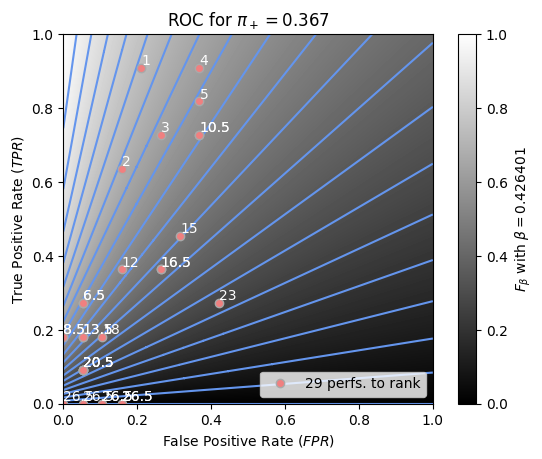

In [14]:
display_roc ( ptn, pfp, pfn, ptp, one_optimal_beta )

## Get the ranges of $\beta$s inducing to the various rankings

In [15]:
def b_to_beta ( b ) :
    return np.sqrt ( b / ( 1 - b ) )

In [16]:
def analyze_b_limits ( theta ) :
    
    b_swaps = theta / ( 1 + theta )
    b_limits = np.unique ( np.concatenate ( (b_swaps, [0,1])) )
    b_centers = ( b_limits[:-1] + b_limits[1:] ) / 2
    num_centers = b_centers.size
    print ( 'There are', num_centers, 'different rankings with the F-beta scores.' )

    max_beta_pr = b_to_beta ( np.min ( b_limits [ b_limits > 0.0 ] ) )
    print ( 'All Fβ with β <', max_beta_pr, 'lead to the same ranking as Pr.' )
    min_beta_re = b_to_beta ( np.max ( b_limits [ b_limits < 1.0 ] ) )
    print ( 'All Fβ with β >', min_beta_re, 'lead to the same ranking as Re.' )

    one_optimal_b = np.median ( b_swaps ) # TODO: or np.median ( b_limits ) ?
    if one_optimal_b in b_swaps :
        print ( 'Optimal β =', b_to_beta(one_optimal_b) )
        min_optimal_b = one_optimal_b
        max_optimal_b = one_optimal_b
        optimal_beta_latex = '$\\beta={:g}$'.format(b_to_beta(one_optimal_b))
    else :
        min_optimal_b = np.max ( b_limits [ b_limits <= one_optimal_b ] )
        max_optimal_b = np.min ( b_limits [ b_limits >= one_optimal_b ] )
        print ( 'Optimal β >', b_to_beta(min_optimal_b) )
        print ( 'Optimal β <', b_to_beta(max_optimal_b) )
        optimal_beta_latex = '$\\beta\\in({:g},{:g})$'.format(b_to_beta(min_optimal_b), b_to_beta(max_optimal_b))

    return optimal_beta_latex

optimal_beta_latex = analyze_b_limits ( theta )

There are 44 different rankings with the F-beta scores.
All Fβ with β < 0.13483997249264446 lead to the same ranking as Pr.
All Fβ with β > 1.5075567228888196 lead to the same ranking as Re.
Optimal β = 0.42640143271122316


## Plot the manifold of rankings induced by $F_\beta$ with two-dimensional PCA

Explained variance ratio: [0.88722275 0.04934929]
Total explained variance ratio: 0.9365720410989343
Precision @ [[-10.31230613   2.30483824]]
Recall @ [[10.32459372  2.98578072]]
Tradeoff @ [[ 0.52781963 -1.59698432]]
F1 @ [[8.18618236 1.73959545]]
Skew-insensitive version of F1 @ [[10.07743387  2.48527414]]


/var/folders/q3/f1blbv4176jcwk6n52fxgw180000gn/T/ipykernel_97598/3210811118.py:19: RuntimeWarning: divide by zero encountered in divide
  return 1.0 / ( (1.0-b)/pr + b/re )
/var/folders/q3/f1blbv4176jcwk6n52fxgw180000gn/T/ipykernel_97598/3210811118.py:19: RuntimeWarning: divide by zero encountered in divide
  return 1.0 / ( (1.0-b)/pr + b/re )
/var/folders/q3/f1blbv4176jcwk6n52fxgw180000gn/T/ipykernel_97598/3210811118.py:19: RuntimeWarning: divide by zero encountered in divide
  return 1.0 / ( (1.0-b)/pr + b/re )
/var/folders/q3/f1blbv4176jcwk6n52fxgw180000gn/T/ipykernel_97598/3210811118.py:19: RuntimeWarning: divide by zero encountered in divide
  return 1.0 / ( (1.0-b)/pr + b/re )


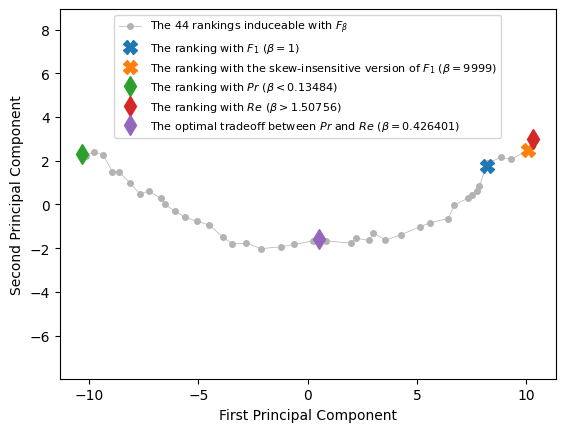

In [17]:
def show_manifold ( pr, re, theta ) :
    
    N = max ( len(pr), len(re) )
    assert len(pr) == N
    assert len(re) == N

    prior_neg, prior_pos = get_priors ( ptn, pfp, pfn, ptp )
    
    b_swaps = theta / ( 1 + theta )
    b_limits = np.unique ( np.concatenate ( (b_swaps, [0,1])) )
    b_centers = ( b_limits[:-1] + b_limits[1:] ) / 2
    num_centers = b_centers.size
    
    def score_f_beta ( b ) :
        #a = 1
        #ok = (1-a) * ptn + a * ptp
        #ko = (1-b) * pfp + b * pfn
        #return ok / (ok+ko)
        return 1.0 / ( (1.0-b)/pr + b/re )
    
    mat_values = np.empty ( [ N, num_centers ] )
    for j in range ( num_centers ) :
        mat_values [ :, j ] = score_f_beta ( b_centers [ j ] )
    
    mat_ranks = np.empty ( [ N, num_centers ] )
    for j in range ( num_centers ) :
        v = mat_values [ :, j ]
        r = values_to_ranks ( v )
        mat_ranks [ :, j ] = r
    
    pca = PCA ( n_components = 2 )
    pca.fit ( mat_ranks.T )
    print ( 'Explained variance ratio:', pca.explained_variance_ratio_ )
    print ( 'Total explained variance ratio:', np.sum ( pca.explained_variance_ratio_ ) )
    points = pca.transform ( mat_ranks.T )
    assert ( points.shape[0] == num_centers )
    assert ( points.shape[1] == 2 )
    
    ranks_pr = np.empty ( [ N, 1 ] )
    ranks_pr [ :, 0 ] = values_to_ranks ( pr )
    point_pr = pca.transform ( ranks_pr.T )
    print ( 'Precision @', point_pr )
    
    ranks_re = np.empty ( [ N, 1 ] )
    ranks_re [ :, 0 ] = values_to_ranks ( re )
    point_re = pca.transform ( ranks_re.T )
    print ( 'Recall @', point_re )
    
    ranks_tradeoff = np.empty ( [ N, 1 ] )
    ranks_tradeoff [ :, 0 ] = values_to_ranks ( score_f_beta(b=one_optimal_b) )
    point_tradeoff = pca.transform ( ranks_tradeoff.T )
    print ( 'Tradeoff @', point_tradeoff )
    
    ranks_fone = np.empty ( [ N, 1 ] )
    ranks_fone [ :, 0 ] = values_to_ranks ( score_f_beta(b=0.5) )
    point_fone = pca.transform ( ranks_fone.T )
    print ( 'F1 @', point_fone )
    
    ranks_sivfone = np.empty ( [ N, 1 ] )
    ranks_sivfone [ :, 0 ] = values_to_ranks ( score_f_beta(b=prior_neg) )
    point_sivfone = pca.transform ( ranks_sivfone.T )
    print ( 'Skew-insensitive version of F1 @', point_sivfone )
    
    fig, ax = plt.subplots ()
    label = 'The {} rankings induceable with $F_\\beta$'.format(num_centers)
    ax.plot ( points[:,0], points[:,1], '-o', color=[0.7,0.7,0.7], markersize=4, linewidth=0.5, label=label )
    label = 'The ranking with $F_1$ ($\\beta=1$)'
    ax.plot ( point_fone[:,0], point_fone[:,1], 'X', markersize=10, label=label )
    beta_sivf = 9999
    label = 'The ranking with the skew-insensitive version of $F_1$ ($\\beta={:g}$)'.format ( beta_sivf )
    ax.plot ( point_sivfone[:,0], point_sivfone[:,1], 'X', markersize=10, label=label )
    label = 'The ranking with $Pr$ ($\\beta<{:g}$)'.format(b_to_beta(b_limits[1]))
    ax.plot ( point_pr[:,0], point_pr[:,1], 'd', markersize=10, label=label )
    label = 'The ranking with $Re$ ($\\beta>{:g}$)'.format(b_to_beta(b_limits[-2]))
    ax.plot ( point_re[:,0], point_re[:,1], 'd', markersize=10, label=label )
    label = 'The optimal tradeoff between $Pr$ and $Re$ ({})'.format(optimal_beta_latex)
    ax.plot ( point_tradeoff[:,0], point_tradeoff[:,1], 'd', markersize=10, label=label )
    ax.set_aspect ( 'equal', adjustable='datalim' )
    #ax.set_title ( 'PCA ({:.2f}% variance explained)'.format ( 100*np.sum ( pca.explained_variance_ratio_ ) ) )
    ax.set_xlabel ( 'First Principal Component' )
    ax.set_ylabel ( 'Second Principal Component' )
    if point_pr[:,0] > point_re[:,0] :
        ax.xaxis.set_inverted ( True )
    ax.legend ( loc='upper center', fontsize=8 )
    #ax.set_xticks ( [] )
    #ax.set_yticks ( [] )
    plt.show ()

show_manifold ( pr, re, theta )

## Show how the value of $F_\beta$ varies w.r.t. $\beta$

/var/folders/q3/f1blbv4176jcwk6n52fxgw180000gn/T/ipykernel_97598/1555581787.py:15: RuntimeWarning: divide by zero encountered in divide
  return 1.0 / ( (1.0-b)/pr + b/re )
/var/folders/q3/f1blbv4176jcwk6n52fxgw180000gn/T/ipykernel_97598/1555581787.py:15: RuntimeWarning: invalid value encountered in divide
  return 1.0 / ( (1.0-b)/pr + b/re )
/var/folders/q3/f1blbv4176jcwk6n52fxgw180000gn/T/ipykernel_97598/1555581787.py:47: RuntimeWarning: invalid value encountered in scalar divide
  beta_sq = - (inv_pr_i - inv_pr_j) / (inv_re_i - inv_re_j)
/var/folders/q3/f1blbv4176jcwk6n52fxgw180000gn/T/ipykernel_97598/1555581787.py:44: RuntimeWarning: divide by zero encountered in scalar divide
  inv_pr_j = 1.0 / pr[j]
/var/folders/q3/f1blbv4176jcwk6n52fxgw180000gn/T/ipykernel_97598/1555581787.py:46: RuntimeWarning: divide by zero encountered in scalar divide
  inv_re_j = 1.0 / re[j]
/var/folders/q3/f1blbv4176jcwk6n52fxgw180000gn/T/ipykernel_97598/1555581787.py:43: RuntimeWarning: divide by zero enc

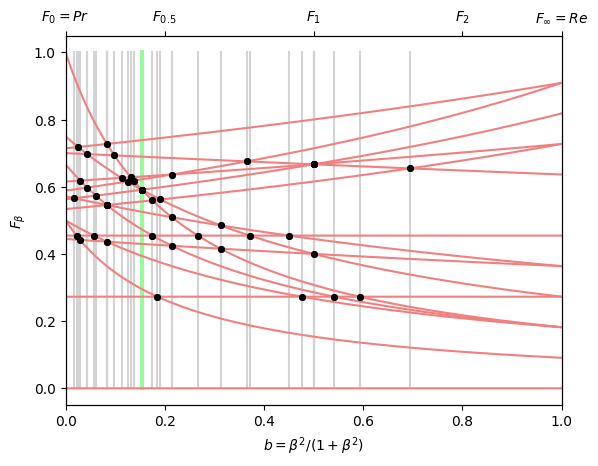

In [18]:
def show_fbeta_curves (pr, re, theta) :
    
    N = max ( len(pr), len(re) )
    assert len(pr) == N
    assert len(re) == N
    
    num_points = 10000
    vec_b = np.linspace ( 0, 1, num_points )
    
    def score_f_beta ( b ) :
        #a = 1
        #ok = (1-a) * ptn + a * ptp
        #ko = (1-b) * pfp + b * pfn
        #return ok / (ok+ko)
        return 1.0 / ( (1.0-b)/pr + b/re )
    
    mat_values = np.empty ( [ N, num_points ] )
    for j in range ( num_points ) :
        b = vec_b [ j ]
        mat_values [ :, j ] = score_f_beta (b)
    
    fig, ax = plt.subplots ()
    
    b_swaps = theta / ( 1 + theta )
    for b in b_swaps :
        ax.plot ( [b,b],[0,1], '-', color='lightgray' )
    
    ax.plot ( [one_optimal_b,one_optimal_b],[0,1], '-', linewidth=3, color='palegreen' )
    
    for i in range ( N ) :
        ax.plot ( vec_b,  mat_values [ i, : ], color='lightcoral' )
    
    for i in range ( N ) :
        for j in range ( N ) :
            # cf. Equation (11) in our paper:
            #     num = ptp[i] * pfp[j] - ptp[j] * pfp[i]
            #     den = ptp[i] * pfn[j] - ptp[j] * pfn[i]
            #     theta[i,j] = - num / den
            # cf. Equation (36) in our paper and Equation (6) in the following paper:
            #     Peter Flach and Meelis Kull. Precision-recall-gain curves: PR analysis done right.
            #     In Advances in Neural Information Processing Systems (NeurIPS), pages 838–846,
            #     Montréal, Canada, 2015. CurranAssociates, Inc.
            inv_pr_i = 1.0 / pr[i]
            inv_pr_j = 1.0 / pr[j]
            inv_re_i = 1.0 / re[i]
            inv_re_j = 1.0 / re[j]
            beta_sq = - (inv_pr_i - inv_pr_j) / (inv_re_i - inv_re_j)
            if np.isfinite(beta_sq) and beta_sq >= 0.0 :
                b_swap = beta_sq / ( 1 + beta_sq )
                v = 1.0 / ( (1.0-b_swap)/pr[i] + b_swap/re[i] )
                ax.plot ( b_swap, v, 'ko', markersize=4 )
    
    ax.set_xlabel ( '$b = \\beta^2 / (1+\\beta^2)$' )
    ax.set_ylabel ( '$F_\\beta$' )
    ax.set_xlim ( [0, 1] )
    ax2 = ax.twiny()
    ax2.set_xticks ( [ 0, 0.2, 0.5, 0.8, 1 ] )
    ax2.set_xticklabels ( [ '$F_0=Pr$', '$F_{0.5}$', '$F_1$', '$F_2$', '$F_\\infty=Re$' ] )
    plt.show ()

show_fbeta_curves (pr, re, theta)


## Show Fréchet variance

/var/folders/q3/f1blbv4176jcwk6n52fxgw180000gn/T/ipykernel_97598/949306587.py:15: RuntimeWarning: divide by zero encountered in divide
  return 1.0 / ( (1.0-b)/pr + b/re )
/var/folders/q3/f1blbv4176jcwk6n52fxgw180000gn/T/ipykernel_97598/949306587.py:15: RuntimeWarning: invalid value encountered in divide
  return 1.0 / ( (1.0-b)/pr + b/re )
100%|███████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:02<00:00, 4026.22it/s]


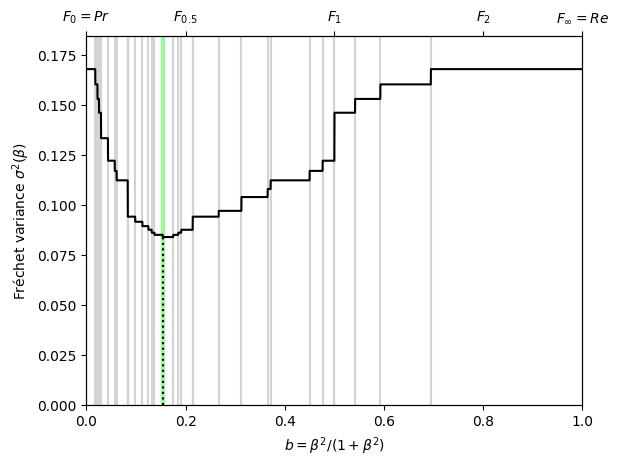

In [19]:
def show_Frechet_variance (theta) :
    
    N = max ( len(pr), len(re) )
    assert len(pr) == N
    assert len(re) == N
    
    num_points = 10000
    vec_b = np.linspace ( 0, 1, num_points )
    
    def score_f_beta ( b ) :
        #a = 1
        #ok = (1-a) * ptn + a * ptp
        #ko = (1-b) * pfp + b * pfn
        #return ok / (ok+ko)
        return 1.0 / ( (1.0-b)/pr + b/re )
    
    mat_values = np.empty ( [ N, num_points ] )
    for j in range ( num_points ) :
        b = vec_b [ j ]
        mat_values [ :, j ] = score_f_beta (b)
    
    tau_pr_re = scipy.stats.kendalltau ( mat_values [ :, 0 ], mat_values [ :, -1 ], nan_policy='omit' ) .correlation
    
    tau_pr = 0 * vec_b
    tau_re = 0 * vec_b
    for j in tqdm ( range ( num_points ) ) :
        tau_pr [ j ] = scipy.stats.kendalltau ( mat_values [ :, j ], mat_values [ :, 0 ], nan_policy='omit' ) .correlation
        tau_re [ j ] = scipy.stats.kendalltau ( mat_values [ :, j ], mat_values [ :, -1 ], nan_policy='omit' ) .correlation
    
    fig, ax = plt.subplots ()
    
    b_swaps = theta / ( 1 + theta )
    for b in b_swaps :
        ax.plot ( [b,b],[0,1], '-', color='lightgray' )
    
    ax.plot ( [one_optimal_b,one_optimal_b],[0,1], '-', linewidth=3, color='palegreen' )
    
    dist_kendall_fbeta_pr = ( 1 - tau_pr ) / 2
    dist_kendall_fbeta_re = ( 1 - tau_re ) / 2
    frechet_variance = dist_kendall_fbeta_pr * dist_kendall_fbeta_pr + dist_kendall_fbeta_re * dist_kendall_fbeta_re
    ax.plot ( vec_b, frechet_variance, 'k-' )
    ax.plot ( [one_optimal_b,one_optimal_b], [0,np.nanmin(frechet_variance)], 'k:' )
    ax.set_xlabel ( '$b = \\beta^2 / (1+\\beta^2)$' )
    ax.set_ylabel ( 'Fréchet variance $\\sigma^2(\\beta)$' )
    ax.set_xlim ( [0, 1] )
    dist_kendall_pr_re = ( 1 - tau_pr_re ) / 2
    max_y = dist_kendall_pr_re * dist_kendall_pr_re * 1.1
    ax.set_ylim ( [0, max_y] )
    ax2 = ax.twiny()
    #ax2.set_ylabel ( '$\\beta=\\sqrt{\\frac{b}{1-b}}$', usetex=True )
    ax2.set_xticks ( [ 0, 0.2, 0.5, 0.8, 1 ] )
    ax2.set_xticklabels ( [ '$F_0=Pr$', '$F_{0.5}$', '$F_1$', '$F_2$', '$F_\\infty=Re$' ] )
    plt.show ()

show_Frechet_variance (theta)

## Show quantiles

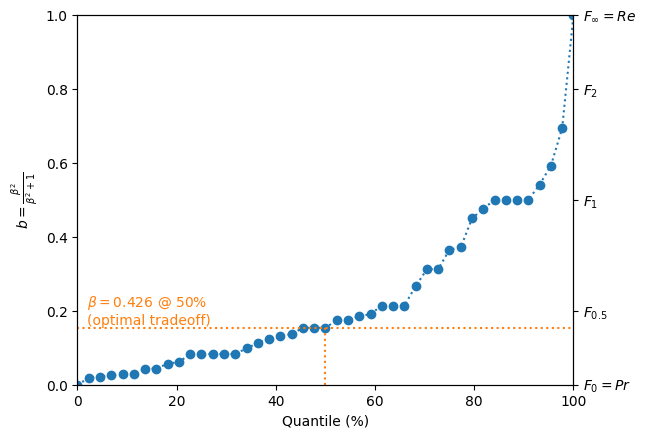

In [20]:
def show_quantiles (theta) :
    
    b_swaps = theta / ( 1 + theta )
    b_limits = np.unique ( np.concatenate ( (b_swaps, [0,1])) )
    quantiles = np.linspace ( 0, 100, len(b_limits) )
    fig, ax = plt.subplots ()
    ax.plot ( quantiles, b_limits, ':o' )
    for quantile in [50]:
        b = np.interp(quantile, quantiles, b_limits)
        beta = b_to_beta ( b )
        l, = ax.plot ( [quantile,quantile], [0,b], ':' )
        color = l.get_color()
        ax.plot ( [0,100], [b,b], ':', color=color )
        txt = '$\\beta={:.3f}$ @ {:g}%'.format(beta,quantile)
        if quantile == 50:
            txt += "\n(optimal tradeoff)"
        ax.text ( 2, b, txt, color=color, va='bottom' )
    ax.set_xlim ( [0, 100] )
    ax.set_ylim ( [0, 1] )
    ax.set_xlabel ( 'Quantile (%)' )
    ax.set_ylabel ( r'$b=\frac{\beta^2}{\beta^2+1}$' )
    ax2 = ax.twinx()
    ax2.set_yticks ( [ 0, 0.2, 0.5, 0.8, 1 ] )
    ax2.set_yticklabels ( [ '$F_0=Pr$', '$F_{0.5}$', '$F_1$', '$F_2$', '$F_\\infty=Re$' ] )
    plt.show ()

show_quantiles (theta)